In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [127]:
# load dataset
car_price = pd.read_csv('updated_car_price_predictions.csv')

In [128]:
# Data Exploration
car_price.head(1000)
car_price.tail(1500)
car_price.sample(1000)
car_price.info()
car_price.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4999 non-null   object 
 1   Year          4999 non-null   int64  
 2   Mileage       4999 non-null   int64  
 3   FuelType      4999 non-null   object 
 4   Transmission  4999 non-null   object 
 5   EngineSize    4999 non-null   float64
 6   HorsePower    4999 non-null   int64  
 7   Condition     4999 non-null   object 
 8   Location      4999 non-null   object 
 9   Price         4999 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.7+ KB


,Year,Mileage,EngineSize,HorsePower,Price
count,4999.000000,4999.000000,4999.000000,4999.000000,4.999000e+03
mean,2016.968394,104856.104421,2.504141,216.049010,1.347768e+07
std,4.295950,54979.191734,0.875100,77.834064,2.785838e+06
min,2010.000000,10015.000000,1.000000,80.000000,5.713104e+06
25%,2013.000000,56996.500000,1.700000,148.000000,1.154335e+07
50%,2017.000000,104464.000000,2.500000,218.000000,1.338790e+07
75%,2021.000000,152386.000000,3.300000,283.000000,1.542868e+07
max,2024.000000,199942.000000,4.000000,350.000000,2.234859e+07


In [129]:
# Data cleaning 
car_price.isnull().sum()
car_price.duplicated().sum()
car_price.drop_duplicates(inplace=True)

In [148]:
# Define target and feature
X = car_price.drop(columns=['Price'])
X = pd.get_dummies(X,columns=['Brand','FuelType','Transmission','Condition','Location'],
                              drop_first=True)
training_columns = X.columns
y = car_price['Price']

In [131]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [132]:
# Create model and train
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_predictions = model.predict(X_test)
#print(f'Predictions: {y_predictions}')

In [134]:
# Evaluate model
mse = mean_squared_error(y_test,y_predictions)
print(f'Mean Square Error: {mse}')
model_accuracy_score = r2_score(y_test,y_predictions)
print(f'Model Accuracy Score: {model_accuracy_score}')

Mean Square Error: 1.2372819213624098e-11
Model Accuracy Score: 1.0


In [135]:
# Check model equations
print(f'Slope of (m): {model.coef_}')
print(f'Intercept of (b): {model.intercept_}')

Slope of (m): [ 1.5e+05 -7.0e+00  2.0e+06  1.0e+04 -3.0e+06  1.0e+06 -2.2e+06  5.0e+05
 -2.6e+06 -1.7e+06 -2.0e+06 -1.0e+06 -2.5e+06 -1.8e+06 -1.2e+06  5.0e+05]
Intercept of (b): -291500000.00001776


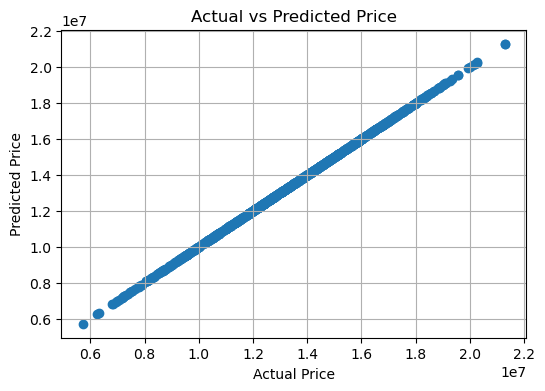

In [141]:
# Visualised graph
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid()
plt.show()

In [154]:
# predict new value
new_car = pd.DataFrame({
    'Year':[2020],
    'Mileage':[50000],
    'EngineSize':[2.5],
    'Horsepower':[180],
    'Brand':['Toyota'],
    'FuelType':['Petrol'],
    'Transmission':['Automatic'],
    'Condition':['Good'],
    'Location':['Abuja']
})
new_car = pd.get_dummies(new_car)
new_car = new_car.reindex(columns=training_columns, fill_value=0)
prediction = model.predict(new_car)

print(f"Predicted Price: ₦{prediction[0]:,.0f}")

Predicted Price: ₦13,450,000


In [155]:
# Save jublic model
joblib.dump(model,"car_price_model.pkl")
joblib.dump(training_columns,"training_columns.pkl")

['training_columns.pkl']